In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scrapper import movie_scrapper
from pathlib import Path

%matplotlib inline

In [3]:
movie_scrapper()

Connection established to Website
Scraping first page
Scraping page with offset 200
Scraping page with offset 400
Scraping page with offset 600
Scraping page with offset 800
Scraping completed successfully!
Rows scraped: 1000
(1000, 8)


In [ ]:
df = pd.read_csv(Path("movie_dataset")/ "top_grossing_movies.csv")

df.head()

,Rank,Title,Worldwide Lifetime Gross,Domestic Lifetime Gross,Domestic %,Foreign Lifetime Gross,Foreign %,Year
0,1,Avatar,"$2,923,710,708","$785,221,649",26.9%,"$2,138,489,059",73.1%,2009
1,2,Avengers: Endgame,"$2,799,439,100","$858,373,000",30.7%,"$1,941,066,100",69.3%,2019
2,3,Avatar: The Way of Water,"$2,334,484,620","$688,459,501",29.5%,"$1,646,025,119",70.5%,2022
3,4,Ne Zha 2,"$2,267,446,370","$23,308,176",1%,"$2,244,138,194",99%,2025
4,5,Titanic,"$2,264,812,968","$674,354,882",29.8%,"$1,590,458,086",70.2%,1997


## **Data Cleaning & Preprocessing**

Firstly checking if there is any inconsistency in data

In [75]:
df.set_index('Rank')

df.head()

,Rank,Title,Worldwide Lifetime Gross,Domestic Lifetime Gross,Domestic %,Foreign Lifetime Gross,Foreign %,Year
0,1,Avatar,"$2,923,710,708","$785,221,649",26.9%,"$2,138,489,059",73.1%,2009
1,2,Avengers: Endgame,"$2,799,439,100","$858,373,000",30.7%,"$1,941,066,100",69.3%,2019
2,3,Avatar: The Way of Water,"$2,334,484,620","$688,459,501",29.5%,"$1,646,025,119",70.5%,2022
3,4,Ne Zha 2,"$2,267,446,370","$23,308,176",1%,"$2,244,138,194",99%,2025
4,5,Titanic,"$2,264,812,968","$674,354,882",29.8%,"$1,590,458,086",70.2%,1997


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Rank                      1000 non-null   str  
 1   Title                     1000 non-null   str  
 2   Worldwide Lifetime Gross  1000 non-null   str  
 3   Domestic Lifetime Gross   1000 non-null   str  
 4   Domestic %                1000 non-null   str  
 5   Foreign Lifetime Gross    1000 non-null   str  
 6   Foreign %                 1000 non-null   str  
 7   Year                      1000 non-null   int64
dtypes: int64(1), str(7)
memory usage: 62.6 KB


In [77]:
df.duplicated().sum()

np.int64(0)

In [79]:
df.columns

Index(['Rank', 'Title', 'Worldwide Lifetime Gross', 'Domestic Lifetime Gross',
       'Domestic %', 'Foreign Lifetime Gross', 'Foreign %', 'Year'],
      dtype='str')

normalizing column names for better readability

In [80]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
    .str.replace('%', 'percent')
)

In [81]:
df.columns

Index(['rank', 'title', 'worldwide_lifetime_gross', 'domestic_lifetime_gross',
       'domestic_percent', 'foreign_lifetime_gross', 'foreign_percent',
       'year'],
      dtype='str')

In [82]:
df.dtypes

rank                          str
title                         str
worldwide_lifetime_gross      str
domestic_lifetime_gross       str
domestic_percent              str
foreign_lifetime_gross        str
foreign_percent               str
year                        int64
dtype: object

Some zero values have '-' as a placeholder which would cause problem during analysis

In [84]:
df['domestic_lifetime_gross'].value_counts(dropna=False)

domestic_lifetime_gross
-               25
$785,221,649     1
$858,373,000     1
$688,459,501     1
$23,308,176      1
                ..
$19,019,882      1
$57,387          1
$99,215,042      1
$65,187,603      1
$45,020,282      1
Name: count, Length: 976, dtype: int64

In [87]:
df['domestic_percent'].value_counts(dropna=False)

domestic_percent
-        26
38.2%    11
<0.1%     9
49%       8
37.6%     8
         ..
80%       1
68.7%     1
56.9%     1
60.9%     1
9.6%      1
Name: count, Length: 429, dtype: int64

There is dollar sign, comma in the money columns and percentage in the average columns, Let's remove them for analysis

Also need to replace '-' values as they represent 0

In [ ]:
currency_columns = ['worldwide_lifetime_gross', 'domestic_lifetime_gross', 'foreign_lifetime_gross']

for col in currency_columns:
    df[col] = (
        df[col]
        .str.replace('-', '0')
        .str.replace('[$,]', '', regex=True)
        .astype(float)
    )

In [96]:
percentage_columns = ['domestic_percent', 'foreign_percent']

for col in percentage_columns:
    df[col] = (
        df[col]
        .str.replace('-', '0')
        .str.replace('<0.1', '0.05')
        .str.replace('%', '', regex=True)
        .astype(float)
    )

In [104]:
df['rank'] = df['rank'].str.replace(',', '')

In [105]:
df.tail()

,rank,title,worldwide_lifetime_gross,domestic_lifetime_gross,domestic_percent,foreign_lifetime_gross,foreign_percent,year
995,996,The Impossible,198087212.0,19019882.0,9.60,179067330.0,90.4,2012
996,997,Lost in Thailand,197757387.0,57387.0,0.05,197700000.0,100.0,2012
997,998,Christopher Robin,197744825.0,99215042.0,50.20,98529783.0,49.8,2018
998,999,Jack the Giant Slayer,197687603.0,65187603.0,33.00,132500000.0,67.0,2013
999,1000,Smurfs: The Lost Village,197183546.0,45020282.0,22.80,152163264.0,77.2,2017


## **Exploratory Data Analysis**

### **Top domestic vs foreign performers**

In [178]:
top_domestic = df.sort_values('domestic_lifetime_gross', ascending=False)[
    ['title', 'year', 'domestic_lifetime_gross']
].head(10)

top_domestic

,title,year,domestic_lifetime_gross
5,Star Wars: Episode VII - The Force Awakens,2015,936662225.0
1,Avengers: Endgame,2019,858373000.0
7,Spider-Man: No Way Home,2021,814866759.0
0,Avatar,2009,785221649.0
14,Top Gun: Maverick,2022,721996984.0
20,Black Panther,2018,700426566.0
2,Avatar: The Way of Water,2022,688459501.0
6,Avengers: Infinity War,2018,678815482.0
4,Titanic,1997,674354882.0
10,Jurassic World,2015,653406625.0


In [168]:
top_foreign = df.sort_values('foreign_lifetime_gross', ascending=False)[
    ['title', 'year', 'foreign_lifetime_gross']
].head(10)

top_foreign

,title,year,foreign_lifetime_gross
3,Ne Zha 2,2025,2.244138e+09
0,Avatar,2009,2.138489e+09
1,Avengers: Endgame,2019,1.941066e+09
2,Avatar: The Way of Water,2022,1.646025e+09
4,Titanic,1997,1.590458e+09
8,Zootopia 2,2025,1.438518e+09
6,Avengers: Infinity War,2018,1.373600e+09
13,Furious 7,2015,1.162335e+09
5,Star Wars: Episode VII - The Force Awakens,2015,1.134648e+09
11,The Lion King,2019,1.118383e+09


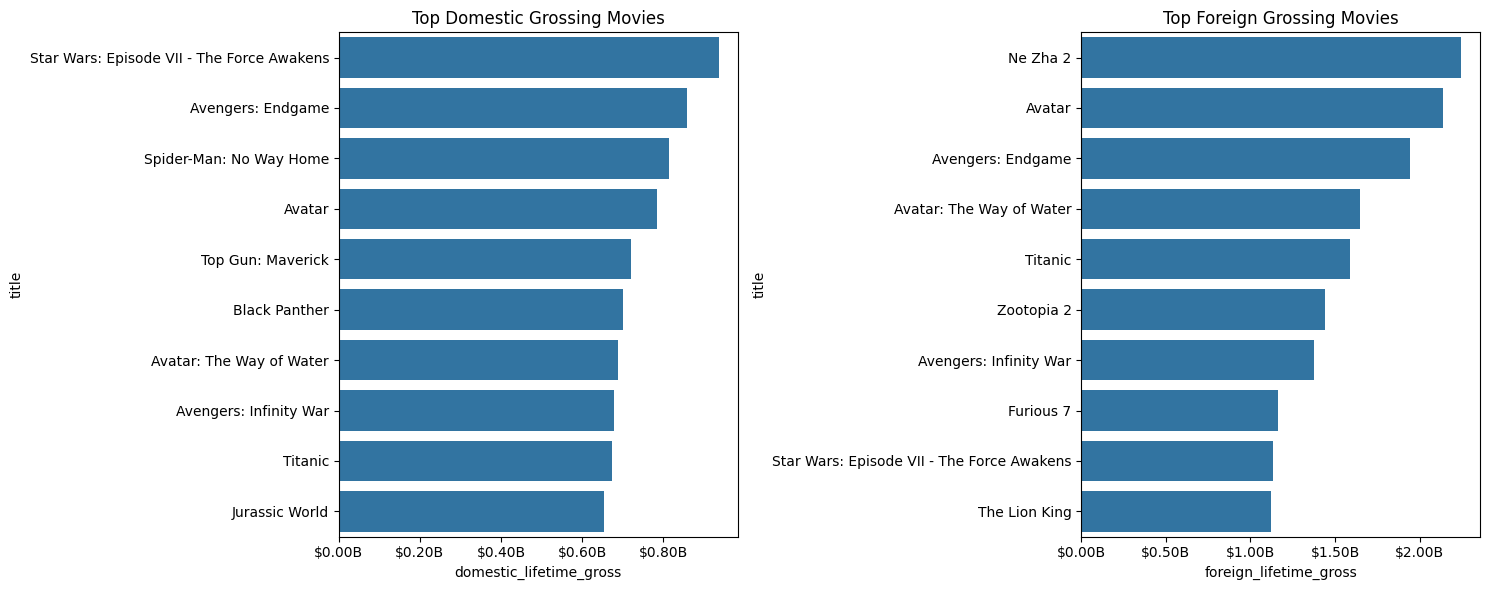

In [181]:
import matplotlib.ticker as mtick

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

def billions(x, pos):
    return f'${x/1e9:.2f}B'

sns.barplot(
    data=top_domestic,
    x='domestic_lifetime_gross',
    y='title',
    ax=axs[0]
)

axs[0].set_title("Top Domestic Grossing Movies")
axs[0].xaxis.set_major_formatter(mtick.FuncFormatter(billions))

sns.barplot(
    data=top_foreign,
    x='foreign_lifetime_gross',
    y='title',
    ax=axs[1]
)

axs[1].set_title("Top Foreign Grossing Movies")
axs[1].xaxis.set_major_formatter(mtick.FuncFormatter(billions))

plt.tight_layout()
plt.show()


Some movies perform better in domestic and some in international platforms, so keeping track of how they are distributed can help set and revenue expectations

In [171]:
df['foreign_to_domestic_ratio'] = (
    df['foreign_lifetime_gross'] /
    df['domestic_lifetime_gross'].replace(0, np.nan)
)

In [172]:
df.sort_values('foreign_to_domestic_ratio', ascending=False)[
    ['title', 'year', 'foreign_to_domestic_ratio']
].head(10)

,title,year,foreign_to_domestic_ratio
326,Dying to Survive,2018,66821.184686
414,Monster Hunt,2015,11811.656595
952,Journey to the West: Conquering the Demons,2013,11386.594584
192,Water Gate Bridge,2022,5340.890438
996,Lost in Thailand,2012,3445.031105
81,The Battle at Lake Changjin,2021,2634.862972
853,"My Country, My Parents",2021,1251.341946
316,The Eight Hundred,2020,1236.868195
874,Too Cool to Kill,2022,1167.776988
781,Jiang Ziya,2020,1120.005986


This tells what's the average lifetime gross revenue movies have generated along with movie count to show how many are being averaged from as to avoid any bias

In [195]:
df.groupby('year').agg(
    {
        'worldwide_lifetime_gross': 'mean',
        'title': 'count'
    }
)

,worldwide_lifetime_gross,title
year,,
1939,4.023822e+08,1
1942,2.674472e+08,1
1961,2.158800e+08,1
1967,2.058436e+08,1
1972,2.509331e+08,1
1973,4.308728e+08,1
1975,4.907363e+08,1
1977,4.398003e+08,3
1978,3.483748e+08,2


Comparing total domestic vs foreign revenue over the year

In [189]:
df.groupby('year')[['domestic_lifetime_gross', 'foreign_lifetime_gross']].sum()

,domestic_lifetime_gross,foreign_lifetime_gross
year,,
1939,2.008822e+08,2.015000e+08
1942,1.022472e+08,1.652000e+08
1961,1.448800e+08,7.100000e+07
1967,1.418436e+08,6.400000e+07
1972,1.363811e+08,1.145520e+08
1973,2.330056e+08,1.978671e+08
1975,2.800833e+08,2.106530e+08
1977,6.904008e+08,6.290000e+08
1978,3.245496e+08,3.722000e+08


Top 10 blockbuster of all time, in this particular dataset they are already set by rank so we can just use `.head()` function with the dataset

In [194]:
df[df['worldwide_lifetime_gross'] > df['worldwide_lifetime_gross'].quantile(0.95)].head(10)

,rank,title,worldwide_lifetime_gross,domestic_lifetime_gross,domestic_percent,foreign_lifetime_gross,foreign_percent,year,foreign_to_domestic_ratio
0,1,Avatar,2.923711e+09,785221649.0,26.9,2.138489e+09,73.1,2009,2.723421
1,2,Avengers: Endgame,2.799439e+09,858373000.0,30.7,1.941066e+09,69.3,2019,2.261332
2,3,Avatar: The Way of Water,2.334485e+09,688459501.0,29.5,1.646025e+09,70.5,2022,2.390882
3,4,Ne Zha 2,2.267446e+09,23308176.0,1.0,2.244138e+09,99.0,2025,96.281159
4,5,Titanic,2.264813e+09,674354882.0,29.8,1.590458e+09,70.2,1997,2.358488
5,6,Star Wars: Episode VII - The Force Awakens,2.071310e+09,936662225.0,45.2,1.134648e+09,54.8,2015,1.211374
6,7,Avengers: Infinity War,2.052415e+09,678815482.0,33.1,1.373600e+09,66.9,2018,2.023524
7,8,Spider-Man: No Way Home,1.921426e+09,814866759.0,42.4,1.106559e+09,57.6,2021,1.357963
8,9,Zootopia 2,1.866648e+09,428130160.0,22.9,1.438518e+09,77.1,2025,3.360001
9,10,Inside Out 2,1.698864e+09,652980194.0,38.4,1.045884e+09,61.6,2024,1.601708


Highest grossing movie by the year count

In [143]:
highest_grossing_movie_by_year = df.loc[
    df.groupby(['year'])['worldwide_lifetime_gross'].idxmax(),
    ['year', 'title', 'worldwide_lifetime_gross'] 
    ]

In [144]:
highest_grossing_movie_by_year = highest_grossing_movie_by_year.sort_values('year', ascending=False)

In [141]:
len(highest_grossing_movie_by_year)

57

if you want to ignore some older movies (1940-1980) as they do not add as much value in analysis as the more recent movies 

In [199]:
highest_grossing_movie_by_year.head(40)

,year,title,worldwide_lifetime_gross
60,2026,The Super Mario Galaxy Movie,1.000531e+09
3,2025,Ne Zha 2,2.267446e+09
9,2024,Inside Out 2,1.698864e+09
17,2023,Barbie,1.447138e+09
2,2022,Avatar: The Way of Water,2.334485e+09
7,2021,Spider-Man: No Way Home,1.921426e+09
283,2020,Demon Slayer: Kimetsu no Yaiba - The Movie: Mu...,4.894944e+08
1,2019,Avengers: Endgame,2.799439e+09
6,2018,Avengers: Infinity War,2.052415e+09
23,2017,Star Wars: Episode VIII - The Last Jedi,1.334408e+09
